# M5 — Prophet + Variables Satelitales
**Proyecto Final — Diplomado AI UNI**

**Autor:** Alvaro Untiveros

| Kernel: `dengue-prophet`

Modelo aditivo de series de tiempo con componentes explícitas:
- Tendencia con changepoints automáticos
- Estacionalidad anual (ciclo epidémico)
- Regresor exógeno: `ndvi_lag4` (señal satelital)

**Limitación conocida:** Prophet modela una serie única — se entrena
sobre la suma nacional de casos. No predice por distrito.
Su valor en este proyecto es como **referencia interpretable** con
componente satelital explícita y cuantificación de incertidumbre.

In [ ]:
#!pip install prophet -q

In [ ]:
from prophet import Prophet
m = Prophet()
print('Prophet OK ✓')

Prophet OK ✓


## 0. Imports

In [ ]:
import warnings, json, os
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from prophet import Prophet
from prophet.plot import plot_plotly, plot_components_plotly

BASE_DIR   = Path('../')
DATA_INTER = BASE_DIR / 'data' / 'interim'
DATA_PROC  = BASE_DIR / 'data' / 'processed'
DATA_PROC.mkdir(parents=True, exist_ok=True)

print('Prophet instalado ✓')

Prophet instalado ✓


## 1. Cargar AMT

In [8]:
df = pd.read_parquet(DATA_INTER / 'AMT_final.parquet')
with open(DATA_INTER / 'AMT_metadata.json') as f:
    meta = json.load(f)

CORTE_TRAIN = meta['corte_train']
CORTE_VAL   = meta['corte_val']

print(f'AMT shape: {df.shape}')

AMT shape: (908980, 84)


## 2. Preparar series temporales

Agregamos a nivel nacional (suma de todos los distritos) y construimos
tres versiones para comparar el efecto de cada regresor satelital.

In [9]:
# Verificar columnas disponibles relacionadas con LST y precipitación
cols_disponibles = [c for c in df.columns if 'lst' in c or 'precip' in c or 'ndvi' in c]
print('Columnas satelitales disponibles:', cols_disponibles[:10])

Columnas satelitales disponibles: ['ndvi', 'seq_lst_norm', 'precip_chirps_mm', 'ndvi_lag4', 'precip_chirps_mm_lag4', 'tmean_x_ndvi']


In [10]:
# Serie nacional agregada por fecha
serie = (
    df[df.fecha.notna()]
    .groupby('fecha')
    .agg(
        y          = ('casos',            'sum'),
        ndvi       = ('ndvi',             'mean'),
        ndwi       = ('ndwi',             'mean'),
        precip_mm  = ('precip_chirps_mm', 'mean'),
        lst_norm   = ('seq_lst_norm',     'mean'),
        tmean      = ('tmean_clima',      'mean'),
        ptot       = ('ptot_clima',       'mean'),
    )
    .reset_index()
    .rename(columns={'fecha': 'ds'})
)

# Lags satelitales (4 semanas)
serie['ndvi_lag4']    = serie['ndvi'].shift(4)
serie['ndwi_lag4']    = serie['ndwi'].shift(4)
serie['precip_lag4']  = serie['precip_mm'].shift(4)
serie['lst_lag4']     = serie['lst_norm'].shift(4)
serie['tmean_lag9']   = serie['tmean'].shift(9)
serie['ptot_lag9']    = serie['ptot'].shift(9)
serie['tmean_x_ndvi'] = serie['tmean_lag9'] * serie['ndvi_lag4']

serie = serie.dropna()

print(f'Serie nacional: {len(serie)} semanas')
print(f'Rango: {serie.ds.min().date()} → {serie.ds.max().date()}')

Serie nacional: 419 semanas
Rango: 2018-03-05 → 2026-03-23


## 3. Split temporal

In [11]:
train_p = serie[serie.ds <= CORTE_TRAIN]
val_p   = serie[(serie.ds > CORTE_TRAIN) & (serie.ds <= CORTE_VAL)]
test_p  = serie[serie.ds > CORTE_VAL]

print(f'Train: {len(train_p)} semanas | {train_p.ds.min().date()} → {train_p.ds.max().date()}')
print(f'Val  : {len(val_p)} semanas')
print(f'Test : {len(test_p)} semanas')

Train: 251 semanas | 2018-03-05 → 2022-12-26
Val  : 52 semanas
Test : 116 semanas


## 4. M5a — Prophet baseline (sin satelital)

Modelo de referencia con solo tendencia y estacionalidad anual.
Sirve para cuantificar el aporte de las variables satelitales.

In [12]:
prophet_base = Prophet(
    yearly_seasonality  = True,
    weekly_seasonality  = False,
    daily_seasonality   = False,
    changepoint_prior_scale = 0.05,
    seasonality_prior_scale = 10,
    uncertainty_samples = 500
)
prophet_base.fit(train_p[['ds','y']])

# Predecir en test
fc_base = prophet_base.predict(test_p[['ds']])

rmse_b = np.sqrt(mean_squared_error(test_p['y'], fc_base['yhat'].clip(0)))
mae_b  = mean_absolute_error(test_p['y'], fc_base['yhat'].clip(0))
r2_b   = r2_score(test_p['y'], fc_base['yhat'].clip(0))
print(f'[Prophet baseline    H=4w] RMSE={rmse_b:.2f} | MAE={mae_b:.2f} | R²={r2_b:.3f}')

[Prophet baseline    H=4w] RMSE=6912.96 | MAE=3131.07 | R²=-0.042


## 5. M5b — Prophet + NDVI lag4

Agrega `ndvi_lag4` como regresor exógeno — el índice de vegetación
4 semanas antes como proxy del hábitat del vector.

In [13]:
prophet_ndvi = Prophet(
    yearly_seasonality      = True,
    weekly_seasonality      = False,
    daily_seasonality       = False,
    changepoint_prior_scale = 0.05,
    seasonality_prior_scale = 10,
    uncertainty_samples     = 500
)
prophet_ndvi.add_regressor('ndvi_lag4')
prophet_ndvi.fit(train_p[['ds','y','ndvi_lag4']])

fc_ndvi = prophet_ndvi.predict(test_p[['ds','ndvi_lag4']])

rmse_n = np.sqrt(mean_squared_error(test_p['y'], fc_ndvi['yhat'].clip(0)))
mae_n  = mean_absolute_error(test_p['y'], fc_ndvi['yhat'].clip(0))
r2_n   = r2_score(test_p['y'], fc_ndvi['yhat'].clip(0))
print(f'[Prophet + NDVI      H=4w] RMSE={rmse_n:.2f} | MAE={mae_n:.2f} | R²={r2_n:.3f}')

[Prophet + NDVI      H=4w] RMSE=6909.54 | MAE=3124.43 | R²=-0.041


## 6. M5c — Prophet + múltiples regresores satelitales

Versión completa con NDVI, precipitación CHIRPS, LST y la
interacción temperatura×vegetación.

In [14]:
REGRESORES = ['ndvi_lag4', 'precip_lag4', 'lst_lag4', 'tmean_x_ndvi']

prophet_full = Prophet(
    yearly_seasonality      = True,
    weekly_seasonality      = False,
    daily_seasonality       = False,
    changepoint_prior_scale = 0.05,
    seasonality_prior_scale = 10,
    uncertainty_samples     = 500
)
for reg in REGRESORES:
    prophet_full.add_regressor(reg)

prophet_full.fit(train_p[['ds','y'] + REGRESORES])

fc_full = prophet_full.predict(test_p[['ds'] + REGRESORES])

rmse_f = np.sqrt(mean_squared_error(test_p['y'], fc_full['yhat'].clip(0)))
mae_f  = mean_absolute_error(test_p['y'], fc_full['yhat'].clip(0))
r2_f   = r2_score(test_p['y'], fc_full['yhat'].clip(0))
print(f'[Prophet + multi-sat H=4w] RMSE={rmse_f:.2f} | MAE={mae_f:.2f} | R²={r2_f:.3f}')

[Prophet + multi-sat H=4w] RMSE=6897.95 | MAE=3105.87 | R²=-0.037


## 7. Comparación de variantes Prophet

El delta entre baseline y versiones con satelital cuantifica
el aporte real de las variables GEE al modelo.

In [15]:
print('Comparación variantes Prophet:')
print(f'  Baseline          : R²={r2_b:.3f} | RMSE={rmse_b:.2f}')
print(f'  + NDVI lag4       : R²={r2_n:.3f} | RMSE={rmse_n:.2f}')
print(f'  + multi-satelital : R²={r2_f:.3f} | RMSE={rmse_f:.2f}')
print(f'\nAporte satelital: ΔR² = {r2_f - r2_b:.3f}')

Comparación variantes Prophet:
  Baseline          : R²=-0.042 | RMSE=6912.96
  + NDVI lag4       : R²=-0.041 | RMSE=6909.54
  + multi-satelital : R²=-0.037 | RMSE=6897.95

Aporte satelital: ΔR² = 0.005


## 8. Visualización — componentes del modelo

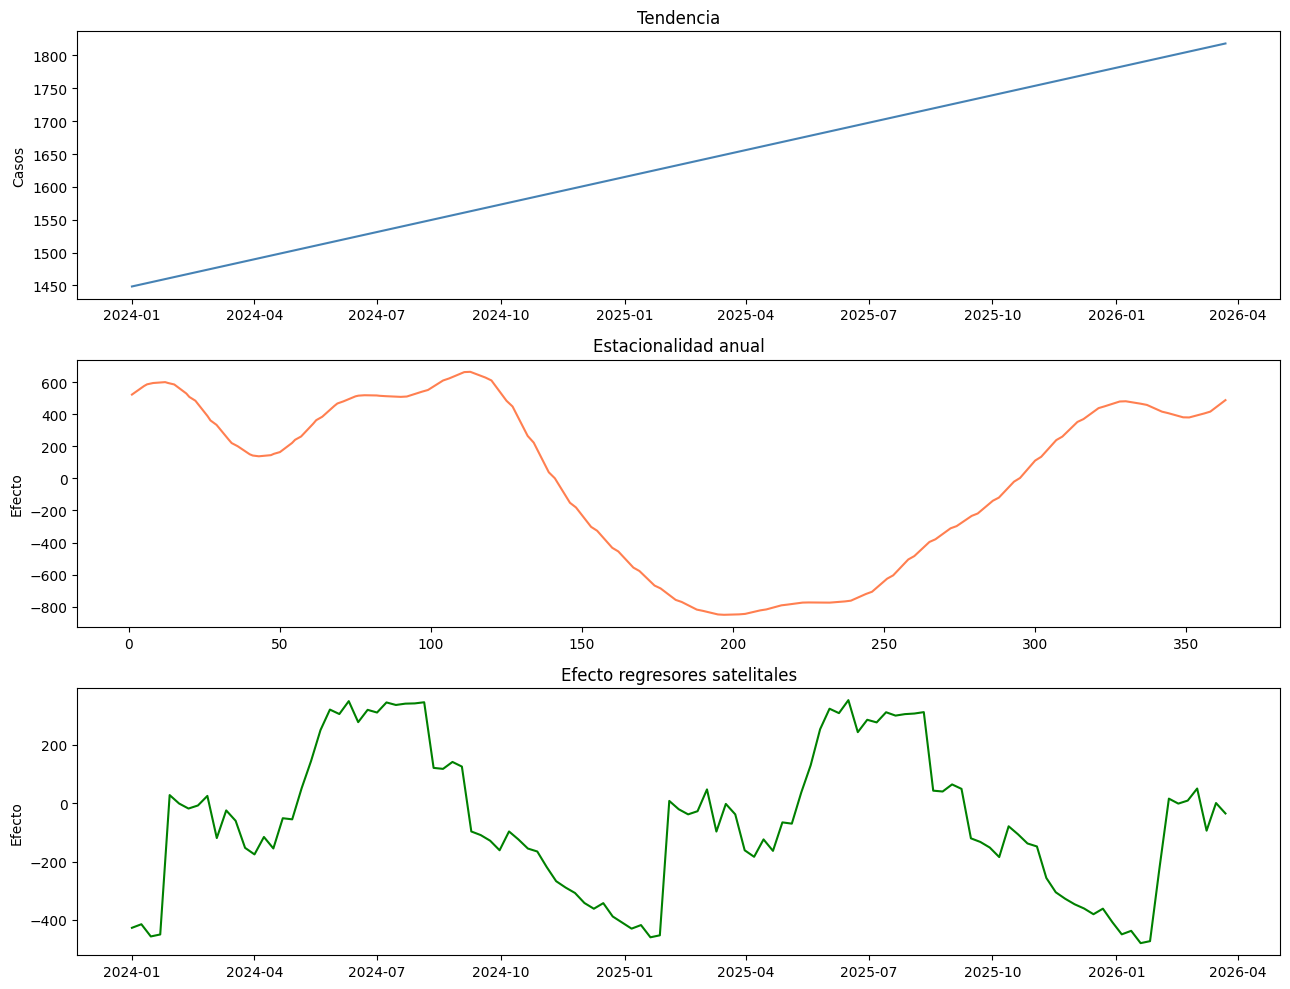

Componentes guardadas ✓


In [17]:
# Componentes del modelo — versión estática sin plotly
fig, axes = plt.subplots(3, 1, figsize=(13, 10))

# Tendencia
axes[0].plot(fc_full['ds'], fc_full['trend'], color='steelblue')
axes[0].set(title='Tendencia', ylabel='Casos')

# Estacionalidad anual
yearly = fc_full[['ds','yearly']].copy()
yearly['dia_año'] = yearly['ds'].dt.dayofyear
yearly_mean = yearly.groupby('dia_año')['yearly'].mean()
axes[1].plot(yearly_mean.index, yearly_mean.values, color='coral')
axes[1].set(title='Estacionalidad anual', ylabel='Efecto')

# Regresor ndvi_lag4
if 'extra_regressors_additive' in fc_full.columns:
    axes[2].plot(fc_full['ds'],
                 fc_full['extra_regressors_additive'],
                 color='green')
    axes[2].set(title='Efecto regresores satelitales', ylabel='Efecto')

plt.tight_layout()
plt.savefig(str(DATA_PROC / 'prophet_componentes.png'), dpi=120, bbox_inches='tight')
plt.show()
print('Componentes guardadas ✓')

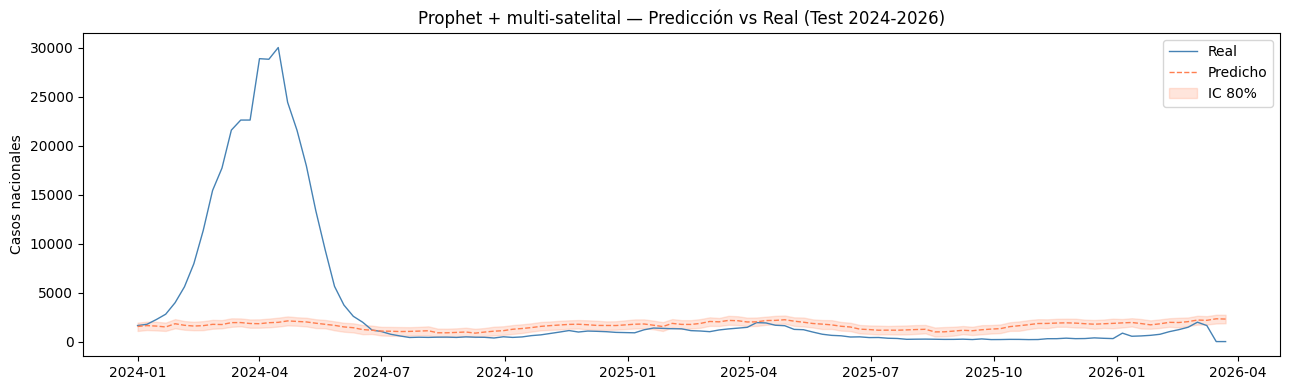

In [18]:
# Predicho vs real en test
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(test_p['ds'], test_p['y'],
        label='Real', color='steelblue', linewidth=1)
ax.plot(test_p['ds'], fc_full['yhat'].clip(0).values,
        label='Predicho', color='coral', linewidth=1, linestyle='--')
ax.fill_between(
    test_p['ds'],
    fc_full['yhat_lower'].clip(0).values,
    fc_full['yhat_upper'].clip(0).values,
    alpha=0.2, color='coral', label='IC 80%'
)
ax.set(title='Prophet + multi-satelital — Predicción vs Real (Test 2024-2026)',
       ylabel='Casos nacionales', xlabel='')
ax.legend()
plt.tight_layout()

## 9. Guardar resultados

In [19]:
import pickle

# Guardar modelo completo
with open(DATA_PROC / 'prophet_full.pkl', 'wb') as f:
    pickle.dump(prophet_full, f)

# Guardar métricas
metricas_prophet = pd.DataFrame([
    {'modelo':'Prophet baseline',         'horizonte':4,
     'rmse':rmse_b, 'mae':mae_b, 'r2':r2_b},
    {'modelo':'Prophet + NDVI',           'horizonte':4,
     'rmse':rmse_n, 'mae':mae_n, 'r2':r2_n},
    {'modelo':'Prophet + multi-satelital','horizonte':4,
     'rmse':rmse_f, 'mae':mae_f, 'r2':r2_f},
])
metricas_prophet.to_csv(DATA_PROC / 'metricas_prophet.csv', index=False)

print('Guardado ✓')
print(metricas_prophet.to_string(index=False))

Guardado ✓
                   modelo  horizonte        rmse         mae        r2
         Prophet baseline          4 6912.959471 3131.065373 -0.041852
           Prophet + NDVI          4 6909.540158 3124.428796 -0.040822
Prophet + multi-satelital          4 6897.945209 3105.865574 -0.037332


In [20]:
# Prophet por distrito — solo HH endémicos
distritos_hh = df[df['cluster_code'] == 4]['ubigeo'].unique()
print(f'Distritos HH: {len(distritos_hh)}')

resultados_hh = []

for ubigeo in distritos_hh:
    serie_dist = (
        df[df['ubigeo'] == ubigeo][['fecha','casos','ndvi_lag4','precip_chirps_mm_lag4','tmean_x_ndvi']]
        .dropna(subset=['fecha'])
        .rename(columns={'fecha':'ds','casos':'y'})
        .sort_values('ds')
    )
    # Rellenar nulos de regresores
    for col in ['ndvi_lag4','precip_chirps_mm_lag4','tmean_x_ndvi']:
        serie_dist[col] = serie_dist[col].fillna(serie_dist[col].median())

    train_d = serie_dist[serie_dist.ds <= CORTE_TRAIN]
    test_d  = serie_dist[serie_dist.ds > CORTE_VAL]

    if len(train_d) < 52 or len(test_d) < 4:
        continue

    try:
        m = Prophet(
            yearly_seasonality=True,
            weekly_seasonality=False,
            daily_seasonality=False,
            changepoint_prior_scale=0.1,
            uncertainty_samples=0  # más rápido sin IC
        )
        for reg in ['ndvi_lag4','precip_chirps_mm_lag4','tmean_x_ndvi']:
            m.add_regressor(reg)

        m.fit(train_d[['ds','y','ndvi_lag4','precip_chirps_mm_lag4','tmean_x_ndvi']])
        fc = m.predict(test_d[['ds','ndvi_lag4','precip_chirps_mm_lag4','tmean_x_ndvi']])

        r2   = r2_score(test_d['y'].values, fc['yhat'].clip(0).values)
        rmse = np.sqrt(mean_squared_error(test_d['y'].values, fc['yhat'].clip(0).values))
        resultados_hh.append({'ubigeo': ubigeo, 'r2': r2, 'rmse': rmse})

    except Exception as e:
        continue

df_hh_res = pd.DataFrame(resultados_hh)
print(f'\nDistritos procesados: {len(df_hh_res)}')
print(f'R² promedio HH: {df_hh_res["r2"].mean():.3f}')
print(f'R² mediana HH : {df_hh_res["r2"].median():.3f}')
print(f'RMSE promedio : {df_hh_res["rmse"].mean():.2f}')

Distritos HH: 94

Distritos procesados: 94
R² promedio HH: -1.003
R² mediana HH : -0.091
RMSE promedio : 36.18


In [23]:
print('Distribución R² distritos HH:')
print(df_hh_res['r2'].describe().round(3))
print(f'\nDistritos con R²>0  : {(df_hh_res["r2"]>0).sum()}')
print(f'Distritos con R²>0.2: {(df_hh_res["r2"]>0.2).sum()}')

Distribución R² distritos HH:
count    94.000
mean     -1.003
std       4.150
min     -25.197
25%      -0.111
50%      -0.091
75%      -0.070
max       0.100
Name: r2, dtype: float64

Distritos con R²>0  : 7
Distritos con R²>0.2: 0


In [ ]:
import pandas as pd
from pathlib import Path

df_hh_res.to_csv('../data/processed/metricas_prophet_hh.csv', index=False)

resumen_prophet = pd.DataFrame([{
    'modelo'   : 'Prophet HH (94 distritos)',
    'horizonte': 4,
    'rmse'     : df_hh_res['rmse'].median(),
    'mae'      : float('nan'),
    'r2'       : df_hh_res['r2'].median(),
    'nota'     : 'Mediana sobre 94 distritos HH. Solo 7/94 con R²>0.'
}])
resumen_prophet.to_csv('../data/processed/metricas_prophet_resumen.csv', index=False)
print('Guardado ✓')
print(resumen_prophet.to_string(index=False))

Guardado ✓
                   modelo  horizonte      rmse  mae        r2                                               nota
Prophet HH (94 distritos)          4 16.228336  NaN -0.090703 Mediana sobre 94 distritos HH. Solo 7/94 con R²>0.
